# Notebook 1: Carga, Exploración y Limpieza de Datos
## Reto 2: Seguridad y Obras Públicas — Bogotá
### Concurso de Datos por la Seguridad — CCB

---

**Objetivo:** Cargar, explorar y limpiar las fuentes de datos principales para el análisis de la relación entre obras de transporte público y percepción de seguridad.

**Fuentes principales (por prioridad para el Reto 2):**
1. 🔴 **Encuesta de Corredores Estratégicos 2024** — 2,105 establecimientos en Metro PLM y Calle 13
2. 🟠 **ECN (Clima de los Negocios) 2020–2024** — Percepción de seguridad empresarial, victimización
3. 🟡 **EMU (Movilidad y Entornos Urbanos) 2024** — Expectativas del metro, seguridad, entorno
4. 🟢 **EPV (Percepción y Victimización) 2021–2025** — Percepción ciudadana, victimización, GPS
5. 🔵 **RNMC (Registro Nacional de Medidas Correctivas)** — ~2.9M comparendos 2020–2025
6. ⚪ **Base Registro Mercantil 2024–2025** — Universo empresarial para MiPymes

In [56]:
# =============================================================================
# 0. CONFIGURACIÓN INICIAL
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

# =============================================================================
# RUTAS — Ajustar según la ubicación de la carpeta 'BD concurso'
# =============================================================================
# Opción 1: Ruta relativa (si el notebook está dentro de /codigo/)
#BASE_DIR = os.path.join('..', 'BD concurso') 

# Opción 2: Ruta absoluta (descomentar y ajustar si es necesario)
BASE_DIR = r'C:\Users\David\Desktop\Universidad\Semestre 2026-10\DATAJAM CCB\BD concurso'

# Verificar que la carpeta existe
assert os.path.isdir(BASE_DIR), f"No se encontró la carpeta base: {BASE_DIR}"
print(f"Carpeta base: {os.path.abspath(BASE_DIR)}")
print(f"Contenido: {os.listdir(BASE_DIR)}")

Carpeta base: C:\Users\David\Desktop\Universidad\Semestre 2026-10\DATAJAM CCB\BD concurso
Contenido: ['Anexos y documentos de consulta', 'Base Registro Mercantil 2024', 'Base Registro Mercantil 2025', 'Datos por la seguridad', 'ECN_Encuesta Clima de los Negocios', 'Encuesta corredores estratégicos', 'ENCUESTA DE GENERO 2025', 'Encuesta de movilidad y entornos urbanos', 'EPV_Encuesta de Percepción y Victimización', 'Instrucciones entrega y formato.docx', 'RNMC']


---
## 1. ENCUESTA DE CORREDORES ESTRATÉGICOS 2024
**La fuente más importante para el Reto 2**

- 2,105 establecimientos comerciales en dos corredores:
  - **Calle 13** (903 establecimientos, 3 tramos)
  - **Primera Línea del Metro — PLM** (1,202 establecimientos, 16 tramos)
- Variables clave: percepción de seguridad, victimización por obras, impacto en negocios
- Variable `TRAMO`: 1 = Calle 13, 2 = Metro PLM
- Variables `PRIMERA` (16 segmentos Metro) y `CALL13` (3 segmentos Calle 13)

In [57]:
# =============================================================================
# 1.1 Cargar datos de Corredores Estratégicos
# =============================================================================
ruta_corredores = os.path.join(
    BASE_DIR, 
    'Encuesta corredores estratégicos', 
    'Base corredores estratégicos anonimizada.xlsx'
)

# Leer con header en fila 2 (0-indexed)
corredores_raw = pd.read_excel(ruta_corredores, sheet_name='NUM', header=2)

print(f"Dimensiones: {corredores_raw.shape}")
print(f"\nPrimeras columnas: {list(corredores_raw.columns[:20])}")
corredores_raw.head()

Dimensiones: (2105, 312)

Primeras columnas: ['NUMERO', 'TRAMO', 'PRIMERA', 'CALL13', 'SPEACH', 'F1_1', 'F1_2', 'F1_3', 'F1_4', 'F1_5', 'F2', 'F4', 'F5', 'F6', 'P1', 'P2', 'P3', 'P4A', 'P4B', 'P4C']


,NUMERO,TRAMO,PRIMERA,CALL13,SPEACH,F1_1,F1_2,F1_3,F1_4,F1_5,F2,F4,F5,F6,P1,P2,P3,P4A,P4B,P4C,P4D,P4E,P5,P6_1,P6_2,...,P65A,P65B,P65C,D1,D2,D3,AUTORIZ,P67_1,P67_OT,P67_OT_TEXT,P68,P69,P70,P71,P72_1,P72_OT,P72_OT_TEXT,P73,P74_1,P74_2,P74_3,P74_4,P74_OT,P74_OT_TEXT,FECHA
0,1,1,-,18,1,1,-,-,-,-,4,1,3,4,3,3,2,0,100,0,0,0,2,-,-,...,1,3,2,2,33,3,1,7,-,-,2,1,1,2,3,-,-,1,1,-,3,-,-,-,27/09/2024 2:51:45 p. m.
1,2,1,-,18,1,1,-,-,-,-,1,1,92,2,1,1,1,0,0,0,0,100,1,-,-,...,2,1,3,1,50,3,1,1,-,-,2,1,1,1,1,-,-,2,-,-,-,-,-,-,27/09/2024 2:59:17 p. m.
2,3,1,-,18,1,1,2,-,-,-,3,1,3,4,1,1,1,0,0,100,0,0,2,-,-,...,1,2,3,2,22,3,2,7,-,-,2,2,1,2,3,-,-,1,-,-,3,-,-,-,27/09/2024 2:54:09 p. m.
3,4,1,-,18,1,-,-,-,90,-,4,1,2,1,5,1,4,0,0,30,70,0,2,-,-,...,2,1,3,1,18,4,1,4,-,-,2,2,1,2,1,-,-,2,-,-,-,-,-,-,27/09/2024 3:56:00 p. m.
4,5,1,-,18,1,1,2,-,-,-,3,1,3,1,4,1,3,25,50,25,0,0,1,1,-,...,1,3,2,1,39,3,2,8,-,-,2,2,2,-,-,-,-,2,-,-,-,-,-,-,27/09/2024 4:18:22 p. m.


In [58]:
# =============================================================================
# 1.2 Seleccionar y renombrar variables relevantes para Reto 2
# =============================================================================

# Variables de identificación y perfil
vars_id = ['NUMERO', 'TRAMO', 'PRIMERA', 'CALL13', 'FECHA', 'F5', 'F6']

# Variables de empleo y transporte
vars_empleo = ['P1', 'P2', 'P3']
vars_transporte_emp = ['P4A', 'P4B', 'P4C', 'P4D', 'P4E']

# Variables de satisfacción con el entorno (1-5, siendo 5 mayor satisfacción)
vars_satisfaccion = [
    'P33A', 'P33B', 'P33C', 'P33D', 'P33E', 'P33F',
    'P33G', 'P33H', 'P33J', 'P33K', 'P33L', 'P34',
]

# Opinión sobre el proyecto (1-5)
vars_opinion = ['P37', 'P40']

# Seguridad y victimización
vars_seguridad = ['P43', 'P43_1A', 'P43_1B', 'P43_1C', 'P43_1D', 'P43_1E', 'P43_1F', 'P43_1G']
vars_victimizacion = ['P44_1', 'P44_2', 'P44_3', 'P44_4', 'P44_5', 'P44_6', 'P44_7', 'P44_8']
vars_soluciones = ['P45_1', 'P45_2', 'P45_3', 'P45_4', 'P45_5', 'P45_6', 'P45_7']

# Impacto económico sobre el negocio (1-5)
vars_economico = ['P30', 'P31', 'P32']

# Demografía
vars_demo = ['D1', 'D2', 'D3']

# Construir lista completa y filtrar existentes
vars_corredores = (vars_id + vars_empleo + vars_transporte_emp + vars_satisfaccion +
                   vars_opinion + vars_seguridad + vars_victimizacion +
                   vars_soluciones + vars_economico + vars_demo)

vars_existentes = [v for v in vars_corredores if v in corredores_raw.columns]
vars_faltantes = [v for v in vars_corredores if v not in corredores_raw.columns]
if vars_faltantes:
    print(f"Variables no encontradas: {vars_faltantes}")

corredores = corredores_raw[vars_existentes].copy()

print(f"\n Dataset de corredores: {corredores.shape}")
corredores.info()


 Dataset de corredores: (2105, 58)
<class 'pandas.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 58 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   NUMERO   2105 non-null   int64 
 1   TRAMO    2105 non-null   int64 
 2   PRIMERA  2105 non-null   object
 3   CALL13   2105 non-null   object
 4   FECHA    2105 non-null   str   
 5   F5       2105 non-null   int64 
 6   F6       2105 non-null   int64 
 7   P1       2105 non-null   int64 
 8   P2       2105 non-null   int64 
 9   P3       2105 non-null   int64 
 10  P4A      2105 non-null   int64 
 11  P4B      2105 non-null   int64 
 12  P4C      2105 non-null   int64 
 13  P4D      2105 non-null   int64 
 14  P4E      2105 non-null   int64 
 15  P33A     2105 non-null   int64 
 16  P33B     2105 non-null   int64 
 17  P33C     2105 non-null   int64 
 18  P33D     2105 non-null   int64 
 19  P33E     2105 non-null   int64 
 20  P33F     2105 non-null   int64 
 21  P33G     210

In [ ]:
# =============================================================================
# 1.3 Exploración y limpieza inicial
# =============================================================================

# Reemplazar "-" por NaN en toda la base
corredores = corredores.replace('-', np.nan)
print(f"✅ Valores '-' reemplazados por NaN")

# Reemplazar valores >= 90 en P1, P2 y P3 por NaN (NS/NR)
for col in ['P1', 'P2', 'P3', 'P37']:
    mask = corredores[col] >= 90
    n = mask.sum()
    corredores.loc[mask, col] = np.nan
    print(f"✅ {col}: {n} valores >= 90 reemplazados por NaN")

# P43 (dummy 1/2): recodificar 2 → 0
corredores['P43'] = pd.to_numeric(corredores['P43'], errors='coerce')
corredores['P43'] = corredores['P43'].replace(2, 0)
print(f"✅ P43: valor 2 reemplazado por 0")

# P43_1X dummy 1 si tiene valor, 0 si es missing
cols_p43 = [c for c in corredores.columns if c.startswith('P43_1')]
for col in cols_p43:
    corredores[col] = corredores[col].notna().astype(int)
print(f"✅ P43_1*: recodificadas como dummy (1=valor, 0=missing) en {cols_p43}")

# P44_X: dummy 1 si tiene valor, 0 si es missing
cols_p44 = [c for c in corredores.columns if c.startswith('P44_')]
for col in cols_p44:
    corredores[col] = corredores[col].notna().astype(int)
print(f"✅ P44_*: recodificadas como dummy (1=valor, 0=missing) en {cols_p44}")

# P45_X: dummy 1 si tiene valor, 0 si es missing
cols_p45 = [c for c in corredores.columns if c.startswith('P45_')]
for col in cols_p45:
    corredores[col] = corredores[col].notna().astype(int)
print(f"✅ P45_*: recodificadas como dummy (1=valor, 0=missing) en {cols_p45}")

# Renombrar TRAMO → corredor
corredores = corredores.rename(columns={'TRAMO': 'corredor'})
print(f"✅ TRAMO renombrada a 'corredor'")

# Crear variable tramo como unión de PRIMERA y CALL13 (mutuamente excluyentes)
corredores['PRIMERA'] = pd.to_numeric(corredores['PRIMERA'], errors='coerce')
corredores['CALL13'] = pd.to_numeric(corredores['CALL13'], errors='coerce')
corredores['tramo'] = corredores['PRIMERA'].combine_first(corredores['CALL13']).astype('Int64')
corredores = corredores.drop(columns=['PRIMERA', 'CALL13'])
print(f"✅ 'tramo' creada (PRIMERA + CALL13); PRIMERA y CALL13 eliminadas")

# Distribución por corredor
print("\n" + "=" * 60)
print("DISTRIBUCIÓN POR CORREDOR")
print("=" * 60)
corredor_labels = {1: 'Calle 13', 2: 'Primera Línea Metro (PLM)'}
print(corredores['corredor'].map(corredor_labels).value_counts())

# Distribución por tramo
print("\n" + "=" * 60)
print("DISTRIBUCIÓN POR TRAMO")
print("=" * 60)
print(corredores.groupby('corredor')['tramo'].value_counts().sort_index())

✅ Valores '-' reemplazados por NaN
✅ P1: 23 valores >= 90 reemplazados por NaN
✅ P2: 428 valores >= 90 reemplazados por NaN
✅ P3: 1267 valores >= 90 reemplazados por NaN
✅ P43: valor 2 reemplazado por 0
✅ P43_1*: recodificadas como dummy (1=valor, 0=missing) en ['P43_1A', 'P43_1B', 'P43_1C', 'P43_1D', 'P43_1E', 'P43_1F', 'P43_1G']
✅ P44_*: recodificadas como dummy (1=valor, 0=missing) en ['P44_1', 'P44_2', 'P44_3', 'P44_4', 'P44_5', 'P44_6', 'P44_7', 'P44_8']
✅ P45_*: recodificadas como dummy (1=valor, 0=missing) en ['P45_1', 'P45_2', 'P45_3', 'P45_4', 'P45_5', 'P45_6', 'P45_7']
✅ TRAMO renombrada a 'corredor'
✅ 'tramo' creada (PRIMERA + CALL13); PRIMERA y CALL13 eliminadas

DISTRIBUCIÓN POR CORREDOR
corredor
Primera Línea Metro (PLM)    1202
Calle 13                      903
Name: count, dtype: int64

DISTRIBUCIÓN POR TRAMO
corredor  tramo
1         17       241
          18        47
          19       615
2         1         75
          2         74
          3         74
         

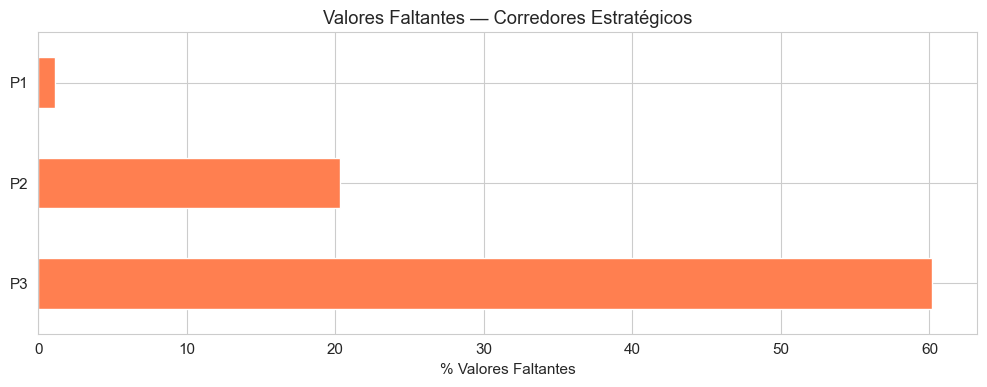


Resumen de nulos:
P1      23
P2     428
P3    1267
dtype: int64


In [60]:
# =============================================================================
# 1.4 Análisis de valores faltantes
# =============================================================================

# Porcentaje de valores faltantes por variable
missing = corredores.isnull().mean().sort_values(ascending=False) * 100
missing_significativo = missing[missing > 0]

if len(missing_significativo) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_significativo) * 0.3)))
    missing_significativo.plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('% Valores Faltantes')
    ax.set_title('Valores Faltantes — Corredores Estratégicos')
    plt.tight_layout()
    plt.show()
else:
    print("No hay valores faltantes significativos")

print(f"\nResumen de nulos:\n{corredores.isnull().sum()[corredores.isnull().sum() > 0]}")

Variables con missing en algún tramo: 17

Missing (%) por tramo:

tramo     1     2     3     4     5     6     7     8     9     10    11    12    13    14    15    16    17    18    19
P1       0.0   0.0   1.4   0.0   1.1   0.0   4.1   0.0   2.9   0.0   1.3   0.0   2.7   2.7   1.3   0.0   0.8   2.1   1.1
P2      22.7  17.6  27.0  22.7  13.8  20.0   8.2  27.5  21.4  43.2  21.3  10.7  34.7  22.7  11.8  24.3  15.4   6.4  20.5
P3      73.3  78.4  75.7  80.0  81.6  64.3  30.1  80.0  65.7  79.7  76.0  52.0  72.0  58.7  22.4  63.5  53.5  14.9  54.8
P43_1A  13.3   0.0   1.4   5.3   0.0   4.3   1.4   1.2   0.0   4.1   0.0   6.7   5.3   0.0   1.3   0.0   5.8   8.5   1.8
P43_1B  13.3   0.0   1.4   5.3   0.0   4.3   1.4   1.2   0.0   4.1   0.0   6.7   5.3   0.0   1.3   0.0   5.8   8.5   1.8
P43_1C  13.3   0.0   1.4   5.3   0.0   4.3   1.4   1.2   0.0   4.1   0.0   6.7   5.3   0.0   1.3   0.0   5.8   8.5   1.8
P43_1D  13.3   0.0   1.4   5.3   0.0   4.3   1.4   1.2   0.0   4.1   0.0   6.7   5.3   

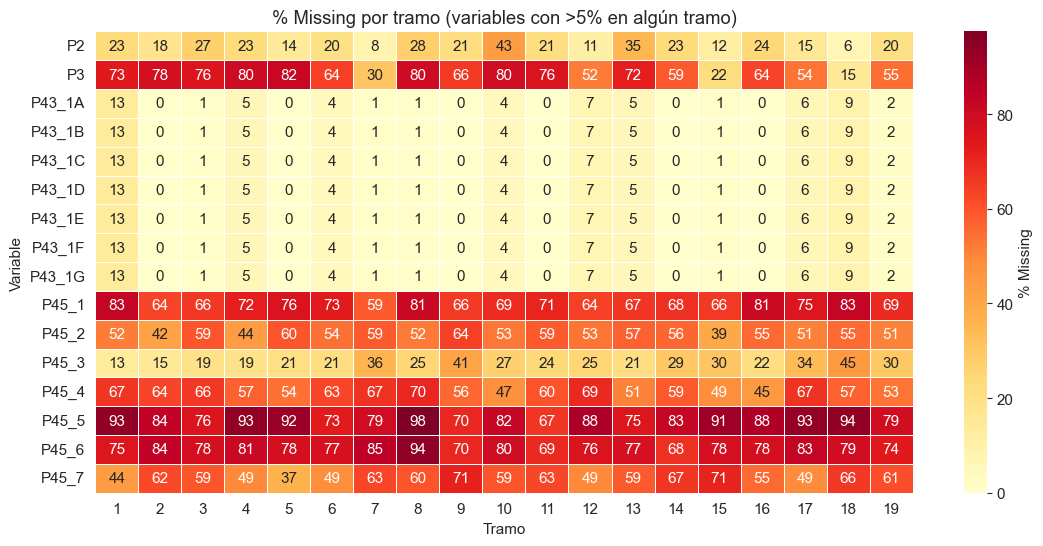


TEST CHI-CUADRADO: uniformidad de missing por tramo
(p < 0.05 → distribución de missing NO es uniforme entre tramos)

Variables con missing NO uniforme entre tramos (p < 0.05):
variable       chi2      p_value  missing_medio_%
      P3 218.009430 2.435936e-36             61.9
   P45_5  99.164135 3.150482e-13             84.0
      P2  65.976483 2.139594e-07             20.6
   P45_7  55.711160 9.898029e-06             57.6
   P45_3  49.078081 1.039225e-04             26.2
   P45_4  44.869263 4.328161e-04             59.0
   P45_6  35.387710 8.444573e-03             78.1
   P45_1  32.953822 1.690640e-02             71.1

Variables con missing uniforme entre tramos (p >= 0.05):
variable      chi2  p_value  missing_medio_%
   P45_2 22.773816 0.199432             53.5


In [55]:
# =============================================================================
# 1.4b Análisis de missing values por tramo
# =============================================================================
from scipy.stats import chi2_contingency

# % de missing por variable y tramo
missing_por_tramo = (
    corredores.groupby('tramo')
    .apply(lambda df: df.isnull().mean() * 100)
    .T  # variables en filas, tramos en columnas
)

# Mantener solo variables con al menos algún missing en algún tramo
missing_por_tramo = missing_por_tramo[missing_por_tramo.max(axis=1) > 0]

print(f"Variables con missing en algún tramo: {len(missing_por_tramo)}")
print(f"\nMissing (%) por tramo:\n")
print(missing_por_tramo.round(1).to_string())

# Tramos con mayor proporción de missing (promedio sobre todas las variables)
missing_media_tramo = corredores.groupby('tramo').apply(lambda df: df.isnull().mean().mean() * 100)
print(f"\n--- % medio de missing por tramo ---")
print(missing_media_tramo.round(2).sort_values(ascending=False))

# Heatmap: variables con missing > 5% en al menos un tramo
thresh = 5
missing_heatmap = missing_por_tramo[missing_por_tramo.max(axis=1) > thresh]

if not missing_heatmap.empty:
    fig, ax = plt.subplots(figsize=(max(10, missing_heatmap.shape[1] * 0.6),
                                    max(4, len(missing_heatmap) * 0.35)))
    sns.heatmap(missing_heatmap, annot=True, fmt='.0f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': '% Missing'})
    ax.set_title(f'% Missing por tramo (variables con >{thresh}% en algún tramo)')
    ax.set_xlabel('Tramo')
    ax.set_ylabel('Variable')
    plt.tight_layout()
    plt.show()
else:
    print(f"No hay variables con más de {thresh}% de missing en ningún tramo.")

# =============================================================================
# Test chi-cuadrado: ¿el patrón de missing es uniforme entre tramos?
# H0: la proporción de missing es igual en todos los tramos (independencia)
# p < 0.05 → el missing NO es uniforme (varía sistemáticamente por tramo)
# =============================================================================
print("\n" + "=" * 70)
print("TEST CHI-CUADRADO: uniformidad de missing por tramo")
print("(p < 0.05 → distribución de missing NO es uniforme entre tramos)")
print("=" * 70)

resultados_chi2 = []
vars_con_missing = missing_por_tramo.index.tolist()

for col in vars_con_missing:
    es_missing = corredores[col].isnull().astype(int)
    tabla = pd.crosstab(corredores['tramo'], es_missing)
    # Solo tiene sentido el test si hay al least ambas categorías (0 y 1)
    if tabla.shape[1] == 2 and tabla.values.min() >= 1:
        chi2, p, dof, _ = chi2_contingency(tabla)
        resultados_chi2.append({'variable': col, 'chi2': chi2, 'p_value': p, 'dof': dof})

resultados_chi2 = pd.DataFrame(resultados_chi2).sort_values('p_value')

# Marcar significancia
resultados_chi2['significativo'] = resultados_chi2['p_value'] < 0.05
resultados_chi2['missing_medio_%'] = resultados_chi2['variable'].map(
    missing_por_tramo.mean(axis=1).round(1)
)

print(f"\nVariables con missing NO uniforme entre tramos (p < 0.05):")
print(resultados_chi2[resultados_chi2['significativo']]
      [['variable', 'chi2', 'p_value', 'missing_medio_%']].to_string(index=False))

print(f"\nVariables con missing uniforme entre tramos (p >= 0.05):")
print(resultados_chi2[~resultados_chi2['significativo']]
      [['variable', 'chi2', 'p_value', 'missing_medio_%']].to_string(index=False))

In [ ]:
# =============================================================================
# 1.5 Crear variables derivadas
# =============================================================================

# Etiquetas legibles para corredores
corredores['corredor_nombre'] = corredores['corredor'].map({
    1: 'Calle 13',
    2: 'Primera Línea Metro'
})

# Tamaño de empresa (MiPyme)
corredores['tamano_empresa'] = corredores['F6'].map({
    1: 'Micro',
    2: 'Pequeña',
    3: 'Mediana',
    4: 'Grande',
    92: 'NS/NR'
})

# Es MiPyme? (Micro, Pequeña o Mediana)
corredores['es_mipyme'] = corredores['F6'].isin([1, 2, 3]).astype(int)

# Seguridad empeoró (dummy)
# seg_cambio: 1=Mejoró, 2=Empeoró, 3=Igual
corredores['seguridad_empeoro'] = (corredores['P43'] == 2).astype(int)

# Fue víctima de algún delito (cualquiera de las columnas vic_* excepto vic_ninguno)
cols_victima = [c for c in vars_victimizacion if c != 'P44_8']
corredores['fue_victima'] = corredores[cols_victima].apply(
    lambda row: 1 if row.sum() > 0 else 0, axis=1
)

# Índice de satisfacción con el entorno (promedio de satisf_*)
corredores['indice_satisfaccion'] = corredores[vars_satisfaccion].mean(axis=1)

# Dummy obras iniciadas según tramo
obras_map = {
    1: 1,
    2: 0, 3: 0,
    4: 1, 5: 1, 6: 1, 7: 1, 8: 1,
    9: 0, 10: 0, 11: 0, 12: 0,
    13: 1,
    14: 0, 15: 0,
    16: 1,
    17: 0, 18: 0,
    19: 1,
}
corredores['obras_iniciadas'] = corredores['tramo'].map(obras_map)

print("Variables derivadas creadas")
print(f"\nMiPymes: {corredores['es_mipyme'].mean()*100:.1f}%")
print(f"Seguridad empeoró: {corredores['seguridad_empeoro'].mean()*100:.1f}%")
print(f"Fue víctima: {corredores['fue_victima'].mean()*100:.1f}%")
print(f"\nDistribución obras_iniciadas:\n{corredores['obras_iniciadas'].value_counts().sort_index()}")

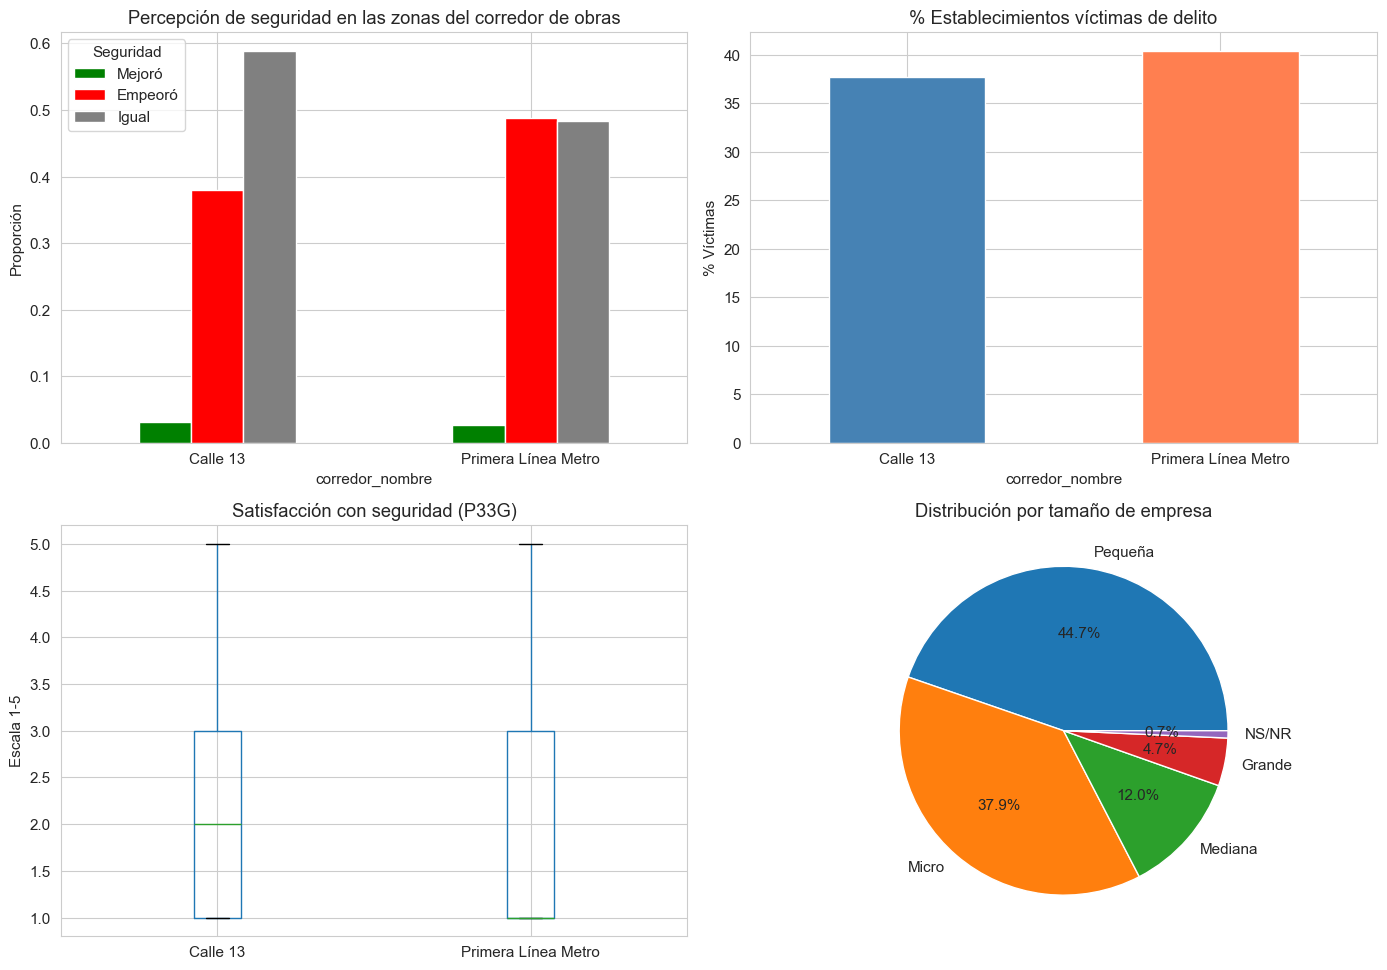

📊 Figura guardada: fig_01_exploracion_corredores.png


In [31]:
# =============================================================================
# 1.6 Visualización exploratoria rápida
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Percepción de seguridad por corredor
ax1 = axes[0, 0]
seg_corredor = corredores.groupby('corredor_nombre')['P43'].value_counts(normalize=True).unstack()
seg_labels = {1: 'Mejoró', 2: 'Empeoró', 3: 'Igual'}
seg_corredor = seg_corredor.rename(columns=seg_labels)
seg_corredor.plot(kind='bar', ax=ax1, color=['green', 'red', 'gray'])
ax1.set_title('Percepción de seguridad en las zonas del corredor de obras')
ax1.set_ylabel('Proporción')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(title='Seguridad')

# 2. Victimización por corredor
ax2 = axes[0, 1]
vic_corredor = corredores.groupby('corredor_nombre')['fue_victima'].mean() * 100
vic_corredor.plot(kind='bar', ax=ax2, color=['steelblue', 'coral'])
ax2.set_title('% Establecimientos víctimas de delito')
ax2.set_ylabel('% Víctimas')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# 3. Satisfacción con seguridad (P33G) por corredor
ax3 = axes[1, 0]
if 'P33G' in corredores.columns:
    corredores.boxplot(column='P33G', by='corredor_nombre', ax=ax3)
    ax3.set_title('Satisfacción con seguridad (P33G)')
    ax3.set_ylabel('Escala 1-5')
    ax3.set_xlabel('')
    plt.suptitle('')  # Quitar título automático de boxplot

# 4. Distribución por tamaño de empresa
ax4 = axes[1, 1]
corredores['tamano_empresa'].value_counts().plot(kind='pie', ax=ax4, autopct='%1.1f%%')
ax4.set_title('Distribución por tamaño de empresa')
ax4.set_ylabel('')

plt.tight_layout()
plt.savefig('fig_01_exploracion_corredores.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Figura guardada: fig_01_exploracion_corredores.png")

In [ ]:
corredores

---
## 2. ENCUESTA DE CLIMA DE LOS NEGOCIOS (ECN) 2024
**Percepción empresarial de seguridad y victimización**

- 2,549 empresas en Bogotá y Cundinamarca
- Variables clave: P56 (percepción seguridad), P57 (tendencia), P58 (victimización)
- Variable de tamaño de empresa: F5 (Micro/Pequeña/Mediana/Grande)
- Sección P33: ambiente de negocios (25 dimensiones)

In [ ]:
# =============================================================================
# 2.1 Cargar ECN 2024
# =============================================================================
ruta_ecn_2024 = os.path.join(
    BASE_DIR,
    'ECN_Encuesta Clima de los Negocios', '2024',
    'Encuesta Clima de negocios 2024 final anonimizada.xlsx'
)

ecn_2024 = pd.read_excel(ruta_ecn_2024, sheet_name='Cod')
print(f"ECN 2024 — Dimensiones: {ecn_2024.shape}")

# Variables más importantes para Reto 2
vars_ecn = [
    'NUMERO', 'REGION', 'F4', 'F5',  # ID, Región, Sector, Tamaño
    'P32',                             # Clima de inversión (1-5)
    'P33_C',                           # Infraestructura urbana (1-5)
    'P33_H',                           # Condiciones de seguridad (1-5)
    'P33_S',                           # Transporte público/privado (1-5)
    'P33_W',                           # Tiempos de desplazamiento (1-5)
    'P56',                             # Percepción: Bogotá segura/insegura
    'P56_1',                           # Escala seguridad 1-5
    'P57',                             # Tendencia inseguridad vs año anterior
    'P58',                             # Fue víctima de delito
    'P60',                             # Denunció
    'FACTOR_TOTAL',                    # Factor de expansión
]

# Variables de victimización por tipo
vars_ecn_delitos = [c for c in ecn_2024.columns if c.startswith('P59_')]
# Variables de costos de inseguridad
vars_ecn_costos = [c for c in ecn_2024.columns if c.startswith('P61B_')]
# Variables de prevención
vars_ecn_prevencion = [c for c in ecn_2024.columns if c.startswith('P61A_')]

vars_ecn_total = vars_ecn + vars_ecn_delitos + vars_ecn_costos + vars_ecn_prevencion
vars_ecn_existentes = [v for v in vars_ecn_total if v in ecn_2024.columns]

ecn = ecn_2024[vars_ecn_existentes].copy()
ecn['anio'] = 2024

print(f"\n✅ ECN 2024 filtrado: {ecn.shape}")
ecn.head()

In [ ]:
# =============================================================================
# 2.2 Cargar ECN años anteriores para análisis temporal
# =============================================================================
ecn_historico = []

for anio in [2020, 2021, 2022]:
    ruta = os.path.join(
        BASE_DIR,
        'ECN_Encuesta Clima de los Negocios', str(anio),
        f'Base_{anio}.xlsx'
    )
    if os.path.exists(ruta):
        try:
            df = pd.read_excel(ruta)
            df['anio'] = anio
            ecn_historico.append(df)
            print(f"  ✅ ECN {anio}: {df.shape}")
        except Exception as e:
            print(f"  ⚠️ ECN {anio}: Error al cargar — {e}")

# ECN 2023 tiene diferente nombre de archivo
ruta_2023 = os.path.join(
    BASE_DIR,
    'ECN_Encuesta Clima de los Negocios', '2023',
    'Base CLIMA DE NEGOCIOS 2023 anonimizada.xlsx'
)
if os.path.exists(ruta_2023):
    try:
        df_2023 = pd.read_excel(ruta_2023, sheet_name=0)  # Primer hoja
        df_2023['anio'] = 2023
        ecn_historico.append(df_2023)
        print(f"  ✅ ECN 2023: {df_2023.shape}")
    except Exception as e:
        print(f"  ⚠️ ECN 2023: Error al cargar — {e}")

print(f"\n📦 Total de años cargados: {len(ecn_historico) + 1} (incluyendo 2024)")

In [ ]:
# =============================================================================
# 2.3 Limpieza y variables derivadas ECN 2024
# =============================================================================

# Tamaño de empresa
ecn['tamano_empresa'] = ecn['F5'].map({
    1: 'Micro', 2: 'Pequeña', 3: 'Mediana', 4: 'Grande'
})
ecn['es_mipyme'] = ecn['F5'].isin([1, 2, 3]).astype(int)

# Sector económico
ecn['sector'] = ecn['F4'].map({
    1: 'Industria', 2: 'Comercio', 3: 'Servicios'
})

# Solo Bogotá (REGION == 1)
ecn_bogota = ecn[ecn['REGION'] == 1].copy()
print(f"ECN 2024 solo Bogotá: {ecn_bogota.shape[0]} empresas")

# Estadísticas clave
print(f"\n--- PERCEPCIÓN DE SEGURIDAD (P56) ---")
if 'P56' in ecn_bogota.columns:
    print(ecn_bogota['P56'].value_counts(normalize=True).round(3) * 100)

print(f"\n--- FUE VÍCTIMA (P58) ---")
if 'P58' in ecn_bogota.columns:
    print(ecn_bogota['P58'].value_counts(normalize=True).round(3) * 100)

print(f"\n--- SEGURIDAD POR TAMAÑO DE EMPRESA ---")
if 'P56_1' in ecn_bogota.columns:
    print(ecn_bogota.groupby('tamano_empresa')['P56_1'].mean().round(2))

---
## 3. ENCUESTA DE MOVILIDAD Y ENTORNOS URBANOS (EMU) 2024
**Percepción ciudadana sobre movilidad, seguridad y expectativas del Metro**

- 18,865 encuestados en las 19 localidades de Bogotá
- 843 variables
- Variables clave: P131 (seguridad en entorno), P133 (expectativas Metro), P134 (medidas de seguridad)

In [ ]:
# =============================================================================
# 3.1 Cargar EMU 2024
# =============================================================================
ruta_emu = os.path.join(
    BASE_DIR,
    'Encuesta de movilidad y entornos urbanos',
    'Resultados Encuesta de movilidad y entornos urbanos 2024 anonimizada.xlsx'
)

emu_raw = pd.read_excel(ruta_emu)
print(f"EMU 2024 — Dimensiones: {emu_raw.shape}")

# Variables de interés para Reto 2
vars_emu_id = ['ID', 'Localidad', 'UPL']

# Seguridad en el entorno urbano (escala 1-5, 22 elementos)
vars_emu_seguridad = [f'P131_{i}' for i in range(1, 23)]

# Expectativas sobre el Metro (13 ítems Si/No)
vars_emu_metro = [f'P133_{i}' for i in range(1, 14)]

# Medidas más importantes para mejorar seguridad en movilidad
vars_emu_medidas = [f'P134_{i}' for i in range(1, 13)]

# Satisfacción con elementos urbanos (27 ítems)
vars_emu_satisf = [f'P130_{i}' for i in range(1, 28)]

# Percepción de seguridad en transporte público
vars_emu_seg_tp = ['P8_1', 'P8_2', 'P8_3']  # Dentro del bus, estaciones, alrededores

# Perspectivas de movilidad
vars_emu_perspectiva = ['P152']  # Movilidad mejoró o empeoró

# Demografía
vars_emu_demo = ['P800', 'P801', 'REDAD', 'P802', 'FACTOR_1', 'FACTOR_2']

# General satisfaction
vars_emu_gral = ['P129']  # Satisfacción general con Bogotá

vars_emu_total = (vars_emu_id + vars_emu_seguridad + vars_emu_metro + vars_emu_medidas + 
                  vars_emu_satisf + vars_emu_seg_tp + vars_emu_perspectiva + 
                  vars_emu_demo + vars_emu_gral)

vars_emu_existentes = [v for v in vars_emu_total if v in emu_raw.columns]
vars_emu_faltantes = [v for v in vars_emu_total if v not in emu_raw.columns]
if vars_emu_faltantes:
    print(f"⚠️ Variables no encontradas: {vars_emu_faltantes[:10]}...")

emu = emu_raw[vars_emu_existentes].copy()
print(f"\n✅ EMU 2024 filtrado: {emu.shape}")

In [ ]:
# =============================================================================
# 3.2 Exploración de expectativas del Metro
# =============================================================================
metro_labels = {
    'P133_1': 'Reducirá trancones',
    'P133_2': 'Viajes más rápidos',
    'P133_3': 'Costos transporte bajarán',
    'P133_4': 'Menos transbordos',
    'P133_5': 'Movilidad más segura',
    'P133_6': 'Menor contaminación',
    'P133_7': 'Nuevos negocios',
    'P133_8': 'Generación de empleo',
    'P133_9': 'Aumento valor inmuebles',
    'P133_10': 'Pérdida valor por ruido',
    'P133_11': 'Muchos transbordos',
    'P133_12': 'Empezaré a usar TP',
    'P133_13': 'Otro',
}

# Calcular % de respuestas "Sí" para cada expectativa
vars_metro_exist = [v for v in vars_emu_metro if v in emu.columns]
expectativas = emu[vars_metro_exist].apply(lambda x: (x == 1).mean() * 100)
expectativas.index = [metro_labels.get(v, v) for v in expectativas.index]

fig, ax = plt.subplots(figsize=(10, 6))
expectativas.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% que responde Sí')
ax.set_title('Expectativas sobre la Primera Línea del Metro — EMU 2024')
plt.tight_layout()
plt.savefig('fig_02_expectativas_metro.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Figura guardada: fig_02_expectativas_metro.png")

---
## 4. EPV — ENCUESTA DE PERCEPCIÓN Y VICTIMIZACIÓN 2025
**Percepción ciudadana y victimización con coordenadas GPS**

- 20,038 encuestados
- 503 variables
- Incluye GPS y localización precisa
- Tiene datos de 2021 a 2025 (panel potencial por localidad)

In [ ]:
# =============================================================================
# 4.1 Cargar EPV 2025
# =============================================================================
ruta_epv = os.path.join(
    BASE_DIR,
    'EPV_Encuesta de Percepción y Victimización', '2025',
    'Base Encuesta de Percepción Victimización 2025 anonimizada.xlsx'
)

epv_raw = pd.read_excel(ruta_epv)
print(f"EPV 2025 — Dimensiones: {epv_raw.shape}")

# Variables de interés
vars_epv_id = ['Localidad', 'UPL']
vars_epv_demo = ['A1', 'A2', 'A3', 'A4']  # Género, edad, educación, estrato
vars_epv_percepcion = [
    'P102',    # Barrio seguro/inseguro
    'P102_1',  # Escala seguridad barrio 1-5
    'P103_1',  # Escala seguridad Bogotá 1-5
    'P106',    # Tendencia inseguridad
    'P111',    # Seguridad TransMilenio 1-5
]
vars_epv_victima = ['P203']  # ¿Fue víctima?
vars_epv_gps = ['_Capture_gps_latitude', '_Capture_gps_longitude']
vars_epv_peso = ['FEX']  # Factor de expansión

vars_epv_total = vars_epv_id + vars_epv_demo + vars_epv_percepcion + vars_epv_victima + vars_epv_gps + vars_epv_peso
vars_epv_existentes = [v for v in vars_epv_total if v in epv_raw.columns]

epv = epv_raw[vars_epv_existentes].copy()
epv['anio'] = 2025
print(f"\n✅ EPV 2025 filtrado: {epv.shape}")
print(f"Registros con GPS: {epv['_Capture_gps_latitude'].notna().sum() if '_Capture_gps_latitude' in epv.columns else 'N/A'}")

In [ ]:
# =============================================================================
# 4.2 Cargar EPV años anteriores (para análisis temporal)
# =============================================================================
epv_panel = []

for anio in [2021, 2022, 2023, 2024]:
    carpeta = os.path.join(BASE_DIR, 'EPV_Encuesta de Percepción y Victimización', str(anio))
    if os.path.isdir(carpeta):
        archivos_xlsx = [f for f in os.listdir(carpeta) if f.endswith('.xlsx') and 'Base' in f]
        if archivos_xlsx:
            ruta = os.path.join(carpeta, archivos_xlsx[0])
            try:
                df = pd.read_excel(ruta)
                df['anio'] = anio
                epv_panel.append(df)
                print(f"  ✅ EPV {anio}: {df.shape}")
            except Exception as e:
                print(f"  ⚠️ EPV {anio}: Error — {e}")

print(f"\n📦 Años EPV cargados: {[df['anio'].iloc[0] for df in epv_panel]}")

---
## 5. RNMC — REGISTRO NACIONAL DE MEDIDAS CORRECTIVAS
**~2.9M comparendos policiales 2020–2025 con localización**

- Datos administrativos de infracciones al Código de Convivencia
- 16 variables: año, mes, día, franja horaria, localidad, UPZ, tipo de infracción
- Permite construir indicadores objetivos de actividad policial/infraccional por zona

In [ ]:
# =============================================================================
# 5.1 Cargar RNMC
# =============================================================================
ruta_rnmc = os.path.join(BASE_DIR, 'RNMC', 'RNMC_anon_V2.csv')

# Archivo grande (~2.9M filas). Cargar con tipos optimizados.
dtypes_rnmc = {
    'ANIO': 'int16',
    'MES': 'int8',
    'DIA_SEMANA': 'category',
    'FRANJA_HORARIA': 'category',
    'COD_LOCALIDAD': 'int16',
    'NOMBRE_LOCALIDAD': 'category',
    'COD_UPZ': 'str',
    'NOMBRE_UPZ': 'category',
    'TITULO': 'category',
    'DESCRIPCION_TITULO': 'category',
}

rnmc = pd.read_csv(ruta_rnmc, dtype=dtypes_rnmc, low_memory=False)
print(f"RNMC — Dimensiones: {rnmc.shape}")
print(f"Memoria: {rnmc.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nRegistros por año:")
print(rnmc['ANIO'].value_counts().sort_index())

In [ ]:
# =============================================================================
# 5.2 Filtrar infracciones relevantes para seguridad
# =============================================================================

# Ver categorías de título (tipo de infracción)
print("TIPOS DE INFRACCIÓN (TITULO):")
print(rnmc['DESCRIPCION_TITULO'].value_counts())

# Infracciones de seguridad
rnmc_seguridad = rnmc[
    rnmc['DESCRIPCION_TITULO'].str.contains('SEGURIDAD', case=False, na=False)
].copy()
print(f"\n✅ Infracciones de seguridad: {len(rnmc_seguridad):,}")

# Infracciones de movilidad
rnmc_movilidad = rnmc[
    rnmc['DESCRIPCION_TITULO'].str.contains('MOVILIDAD', case=False, na=False)
].copy()
print(f"✅ Infracciones de movilidad: {len(rnmc_movilidad):,}")

In [ ]:
# =============================================================================
# 5.3 Agregar indicadores por localidad y año
# =============================================================================

# Total comparendos por localidad y año
rnmc_localidad = rnmc.groupby(['ANIO', 'NOMBRE_LOCALIDAD']).size().reset_index(name='total_comparendos')

# Comparendos de seguridad por localidad y año
rnmc_seg_loc = rnmc_seguridad.groupby(['ANIO', 'NOMBRE_LOCALIDAD']).size().reset_index(name='comparendos_seguridad')

# Comparendos de movilidad por localidad y año
rnmc_mov_loc = rnmc_movilidad.groupby(['ANIO', 'NOMBRE_LOCALIDAD']).size().reset_index(name='comparendos_movilidad')

# Merge
rnmc_indicadores = rnmc_localidad.merge(rnmc_seg_loc, on=['ANIO', 'NOMBRE_LOCALIDAD'], how='left')
rnmc_indicadores = rnmc_indicadores.merge(rnmc_mov_loc, on=['ANIO', 'NOMBRE_LOCALIDAD'], how='left')
rnmc_indicadores = rnmc_indicadores.fillna(0)

print(f"✅ Indicadores RNMC por localidad-año: {rnmc_indicadores.shape}")
rnmc_indicadores.head(10)

In [ ]:
# =============================================================================
# 5.4 Indicadores por UPZ (más granular)
# =============================================================================

# Total y seguridad por UPZ y año
rnmc_upz = rnmc.groupby(['ANIO', 'NOMBRE_UPZ', 'NOMBRE_LOCALIDAD']).size().reset_index(name='total_comparendos')
rnmc_seg_upz = rnmc_seguridad.groupby(['ANIO', 'NOMBRE_UPZ']).size().reset_index(name='comparendos_seguridad')

rnmc_upz = rnmc_upz.merge(rnmc_seg_upz, on=['ANIO', 'NOMBRE_UPZ'], how='left').fillna(0)
rnmc_upz['tasa_seguridad'] = rnmc_upz['comparendos_seguridad'] / rnmc_upz['total_comparendos']

print(f"✅ Indicadores RNMC por UPZ-año: {rnmc_upz.shape}")
print(f"\nUPZs únicas: {rnmc_upz['NOMBRE_UPZ'].nunique()}")

---
## 6. GUARDAR DATOS LIMPIOS

Guardamos los datos procesados en formato `.parquet` o `.csv` para usarlos en el siguiente notebook.

In [ ]:
# =============================================================================
# 6.1 Guardar todos los datasets limpios
# =============================================================================
output_dir = os.path.join('.', 'datos_limpios')
os.makedirs(output_dir, exist_ok=True)

# Corredores
corredores.to_csv(os.path.join(output_dir, 'corredores_limpio.csv'), index=False)
print(f"✅ corredores_limpio.csv — {corredores.shape}")

# ECN 2024
ecn_bogota.to_csv(os.path.join(output_dir, 'ecn_2024_bogota.csv'), index=False)
print(f"✅ ecn_2024_bogota.csv — {ecn_bogota.shape}")

# EMU 2024
emu.to_csv(os.path.join(output_dir, 'emu_2024_filtrado.csv'), index=False)
print(f"✅ emu_2024_filtrado.csv — {emu.shape}")

# EPV 2025
epv.to_csv(os.path.join(output_dir, 'epv_2025_filtrado.csv'), index=False)
print(f"✅ epv_2025_filtrado.csv — {epv.shape}")

# RNMC indicadores
rnmc_indicadores.to_csv(os.path.join(output_dir, 'rnmc_indicadores_localidad.csv'), index=False)
rnmc_upz.to_csv(os.path.join(output_dir, 'rnmc_indicadores_upz.csv'), index=False)
print(f"✅ rnmc_indicadores_localidad.csv — {rnmc_indicadores.shape}")
print(f"✅ rnmc_indicadores_upz.csv — {rnmc_upz.shape}")

print(f"\n🎉 Todos los datos guardados en: {os.path.abspath(output_dir)}")

---
## Resumen del Notebook 1

| Dataset | Registros | Variables seleccionadas | Archivo de salida |
|---------|-----------|----------------------|------------------|
| Corredores Estratégicos 2024 | 2,105 | ~50+ | `corredores_limpio.csv` |
| ECN 2024 (Bogotá) | ~2,000+ | ~30+ | `ecn_2024_bogota.csv` |
| EMU 2024 | 18,865 | ~80+ | `emu_2024_filtrado.csv` |
| EPV 2025 | 20,038 | ~15 | `epv_2025_filtrado.csv` |
| RNMC (indicadores) | ~400+ | 5 | `rnmc_indicadores_*.csv` |

### Próximo paso → Notebook 02: Consolidación, Modelos Econométricos y Clustering